<a href="https://colab.research.google.com/github/farrelta/cv-assigments/blob/main/CVL_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Implementing Otsu's Thresholding

Otsu's method is a global thresholding technique that automatically determines the optimal threshold value by minimizing the intra-class variance of the two classes (foreground and background) in a grayscale image.

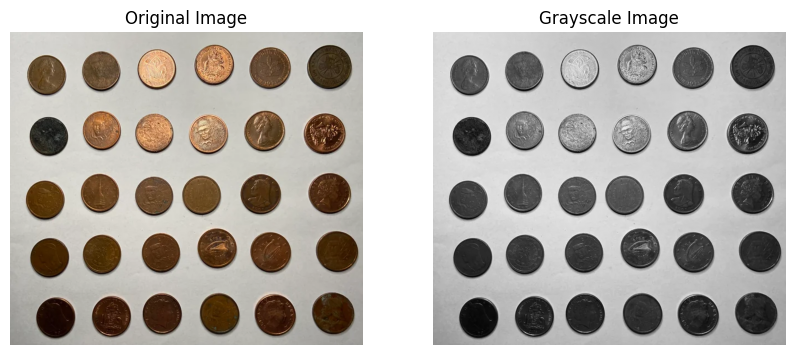

In [82]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/coins.jpg"

img = cv2.imread(image_path)

# Convert the image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Grayscale Image')
plt.imshow(gray_img, cmap='gray')
plt.axis('off')
plt.show()

This `otsu_thresholding` function implements Otsu's method. It calculates the image histogram, normalizes it, and then iterates through all possible threshold values (0-255) to find the optimal threshold. The optimal threshold is determined by maximizing the inter-class variance between the two classes (foreground and background). Finally, it applies this best threshold to the image to produce a binary output.




In [83]:
def otsu_thresholding(image):
    # Ensure image is 8-bit grayscale
    if image.dtype != np.uint8:
        image = image.astype(np.uint8)

    # Calculate histogram
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist_norm = hist.ravel() / hist.sum()

    # Calculate total number of pixels
    total_pixels = image.shape[0] * image.shape[1]

    best_thresh = 0
    max_inter_class_variance = 0

    for t in range(256): # Iterate through all possible threshold values
        # Class 1 (background) pixels
        w0 = hist_norm[:t+1].sum()
        if w0 == 0:
            mu0 = 0
            variance0 = 0
        else:
            mu0 = np.sum(np.arange(t+1) * hist_norm[:t+1]) / w0
            variance0 = np.sum(((np.arange(t+1) - mu0)**2) * hist_norm[:t+1]) / w0

        # Class 2 (foreground) pixels
        w1 = hist_norm[t+1:].sum()
        if w1 == 0:
            mu1 = 0
            variance1 = 0
        else:
            mu1 = np.sum(np.arange(t+1, 256) * hist_norm[t+1:]) / w1
            variance1 = np.sum(((np.arange(t+1, 256) - mu1)**2) * hist_norm[t+1:]) / w1

        # Otsu's maximizes inter-class variance
        inter_class_variance_otsu = w0 * w1 * ((mu0 - mu1)**2)

        if inter_class_variance_otsu > max_inter_class_variance:
            max_inter_class_variance = inter_class_variance_otsu
            best_thresh = t

    # Apply the best threshold to the image
    thresholded_image = np.zeros_like(image)
    thresholded_image[image < best_thresh] = 255

    return best_thresh, thresholded_image

In [84]:
optimal_otsu_thresh, otsu_thresholded_img = otsu_thresholding(gray_img)
print(f"Otsu's Threshold: {optimal_otsu_thresh}")

Otsu's Threshold: 126


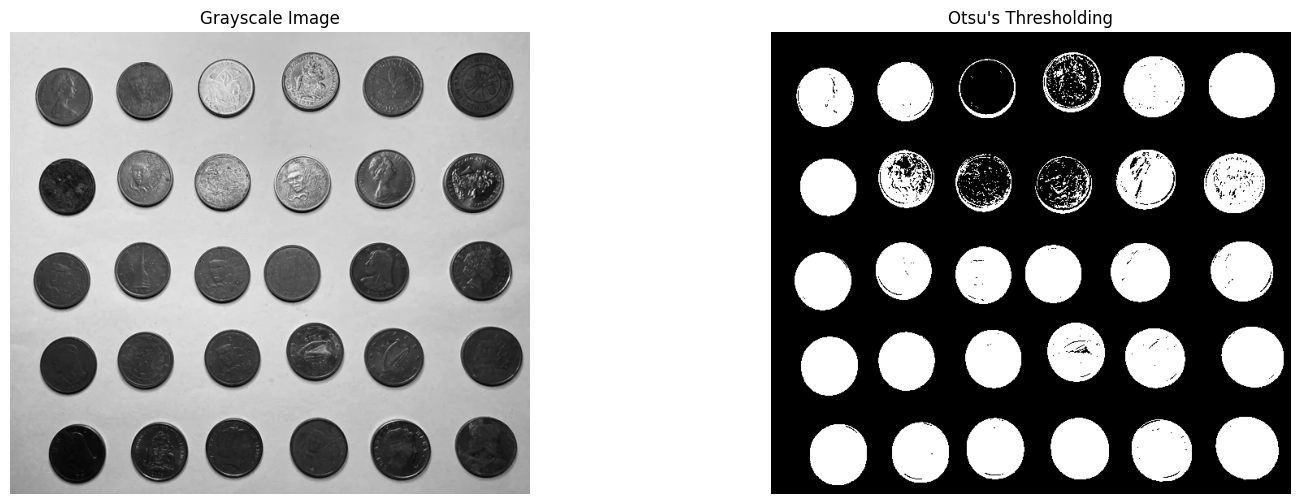

In [85]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.title('Grayscale Image')
plt.imshow(gray_img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Otsu\'s Thresholding')
plt.imshow(otsu_thresholded_img, cmap='gray')
plt.axis('off')
plt.show()

### Evaluation Metrics: IoU and Accuracy

To assess the quality of image segmentation, we'll calculate:

1.  **Intersection over Union (IoU)**: Also known as the Jaccard index, it measures the similarity between the predicted segmentation mask and the ground truth mask. A higher IoU indicates better overlap.
2.  **Accuracy**: This metric calculates the proportion of correctly classified pixels (both foreground and background) in the predicted mask compared to the ground truth mask.


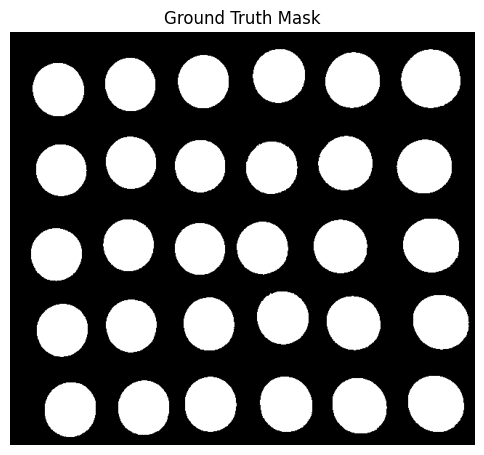

In [86]:

ground_truth_path = '/content/coins_evaluate.jpg'

gt_img_color = cv2.imread(ground_truth_path)
gt_img_gray = cv2.cvtColor(gt_img_color, cv2.COLOR_BGR2GRAY)
_, ground_truth_mask = cv2.threshold(gt_img_gray, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(6, 6))
plt.title('Ground Truth Mask')
plt.imshow(ground_truth_mask, cmap='gray')
plt.axis('off')
plt.show()

In [87]:
def calculate_iou(predicted_mask, ground_truth_mask):
    predicted_mask = predicted_mask.astype(bool)
    ground_truth_mask = ground_truth_mask.astype(bool)

    intersection = np.logical_and(predicted_mask, ground_truth_mask).sum()
    union = np.logical_or(predicted_mask, ground_truth_mask).sum()

    return intersection / union

def calculate_accuracy(predicted_mask, ground_truth_mask):
    predicted_mask = predicted_mask.astype(bool)
    ground_truth_mask = ground_truth_mask.astype(bool)

    correct_pixels = np.sum(predicted_mask == ground_truth_mask)
    total_pixels = predicted_mask.size
    return correct_pixels / total_pixels

In [88]:
iou_otsu = calculate_iou(otsu_thresholded_img, ground_truth_mask)
accuracy_otsu = calculate_accuracy(otsu_thresholded_img, ground_truth_mask)

print(f"  IoU: {iou_otsu:.4f}")
print(f"  Accuracy: {accuracy_otsu:.4f}")

  IoU: 0.8717
  Accuracy: 0.9553
